In [ ]:
import pandas as pd
import plotly.express as px
df=pd.read_csv("../data/processed/nav_history_clean.csv")
df["date"]=pd.to_datetime(df['date'])
df=df[(df['date'].dt.year>=2022) &(df['date'].dt.year <=2026)]
fig=px.line(
    df,
    x="date",
    y="nav",
    color="amfi_code"
)

fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.3,
    line_width=0,
    annotation_text='2023 Bull Run',
    annotation_position='left'
)

fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    fillcolor='red',
    opacity=0.3,
    line_width=0,
    annotation_text='2024 Market Correction',
    annotation_position='top left'
)

fig.update_layout(
    title='NAV Trend Analysis',
    xaxis_title='date',
    yaxis_title='nav',
    hovermode='x unified'
 
)
plt.savefig("../images/aum_growth.png", dpi=300)
fig.show()

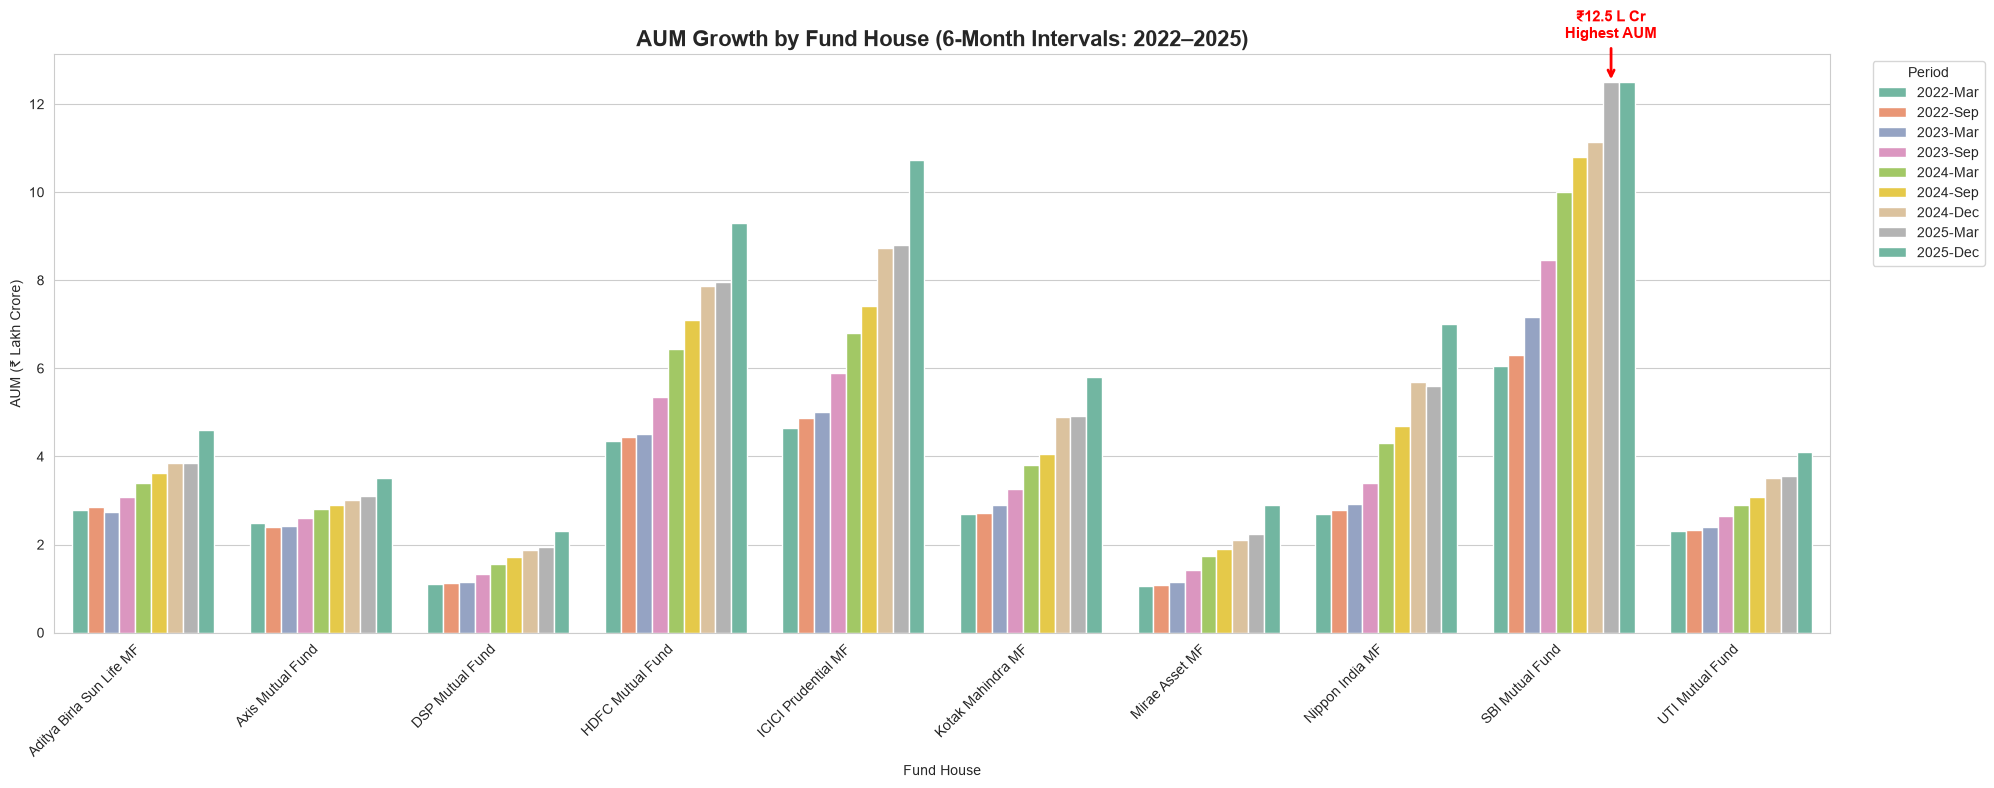

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Keep only years 2022-2025
df = df[df["date"].dt.year.between(2022, 2025)]

# Create labels for every 6-month period
df["period"] = (
    df["date"].dt.year.astype(str)
    + "-"
    + df["date"].dt.strftime("%b")
)

# Sort data
df = df.sort_values(["date", "fund_house"])

# Plot
plt.figure(figsize=(20, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df,
    x="fund_house",
    y="aum_lakh_crore",
    hue="period",
    palette="Set2"
)

# Highlight SBI's latest value (₹12.5 L Cr)
sbi_latest = df[
    (df["fund_house"] == "SBI Mutual Fund") &
    (df["date"] == df['date'].max())
]

if not sbi_latest.empty:
    for p in ax.patches:
        height = p.get_height()

        if abs(height - 12.5) < 0.01:
            x = p.get_x() + p.get_width()/2

            ax.annotate(
                "₹12.5 L Cr\nHighest AUM",
                xy=(x, height),
                xytext=(x, height + 1),
                ha="center",
                color="red",
                fontsize=11,
                fontweight="bold",
                arrowprops=dict(
                    arrowstyle="->",
                    color="red",
                    lw=2
                )
            )
            break

# Formatting
plt.title(
    "AUM Growth by Fund House (6-Month Intervals: 2022–2025)",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Period",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

# Convert month column to datetime
df["month"] = pd.to_datetime(df["month"])

# Filter data from Jan 2022 to Dec 2025
df = df[
    (df["month"] >= "2022-01-01") &
    (df["month"] <= "2025-12-31")
]

# Create line chart
fig = px.line(
    df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    markers=True
)

# Get Dec 2025 record
dec_2025 = df[df["month"] == "2025-12-01"]

# Annotate the all-time high
fig.add_annotation(
    x=dec_2025["month"].iloc[0],
    y=dec_2025["sip_inflow_crore"].iloc[0],
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60,
    bgcolor="yellow",
    bordercolor="black",
    font=dict(size=12, color="black")
)

# Update layout
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified",
    template="plotly_white",
    width=1200,
    height=700
)

# Show graph
fig.show()

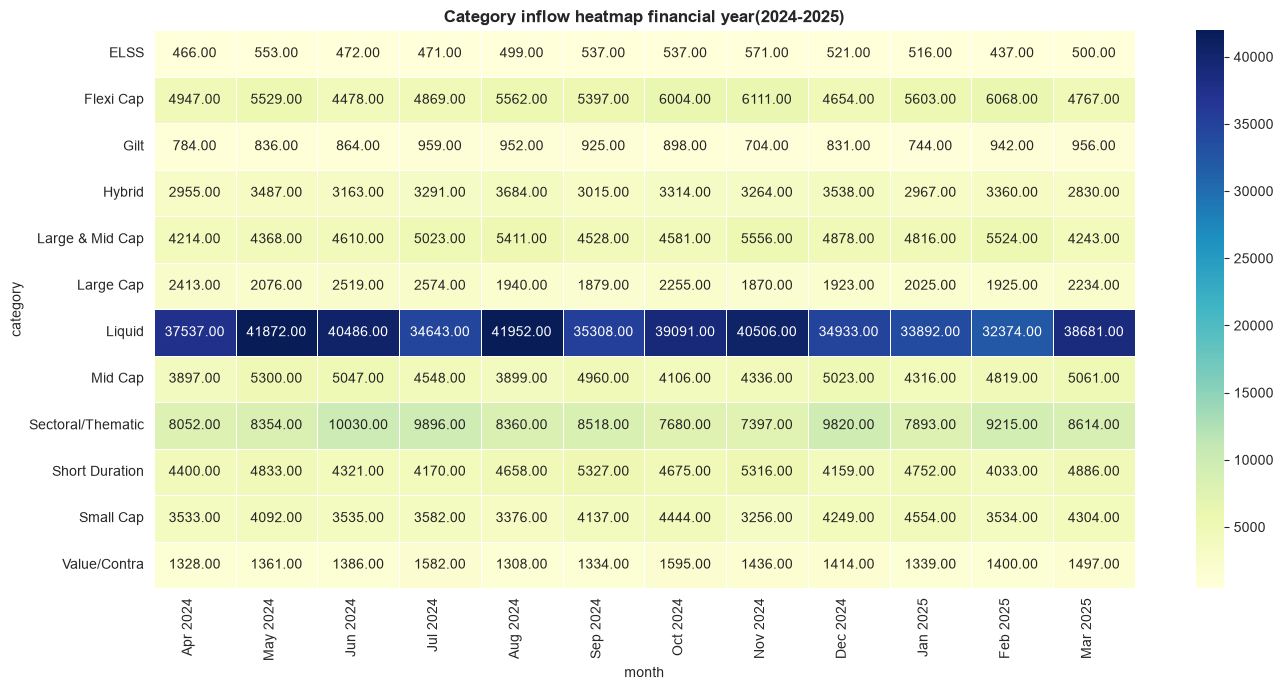

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("../data/raw/05_category_inflows.csv")

df['month']=pd.to_datetime(df['month'],format="%Y-%m")

heatmap_data=df.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    
)
heatmap_data.columns=heatmap_data.columns.strftime("%b %Y")

plt.figure(
    figsize= (14,7)
)

sns.heatmap(
    data=heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths='0.5',
    linecolor="white",
    cbar=True
)


plt.title(
    'Category inflow heatmap financial year(2024-2025)',
    fontsize=12,
    fontweight='bold'

)

plt.xlabel('month')
plt.ylabel('category')

plt.xticks(
    rotation=90,
    ha='right'
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


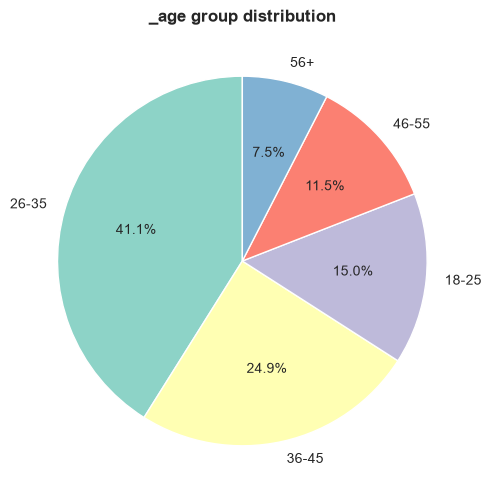

In [49]:
# investor demographics-age group distribution(pie chart)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("../data/processed/clean_investor_transactions.csv")
df.columns

age_counts=df['age_group'].value_counts()
print(age_counts)

plt.figure(
    figsize=(6,6)
)

plt.pie(
    age_counts,
    labels=['26-35','36-45', '18-25','46-55','56+'],
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set3.colors,
    explode=(0,0,0,0,0)
)

plt.title(
    "_age group distribution",
    fontsize=12,
    fontweight="bold"
)

plt.show() 

597498


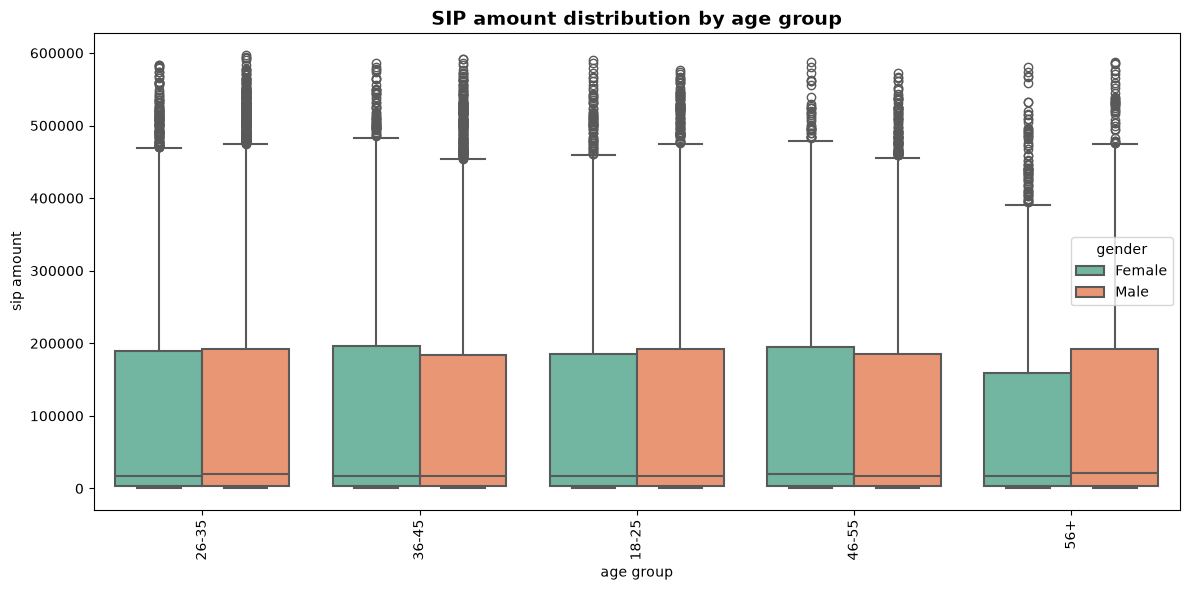

In [14]:
#4.2-SIP amount distribution by  by age group(box plot)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../data/processed/clean_investor_transactions.csv")
print(df['amount_inr'].max())


age_order=['26-35','36-45', '18-25','46-55','56+']


plt.figure(figsize=(12,6))

sns.boxplot(
    df,
    x='age_group',
    y='amount_inr',
    hue='gender',
    order=age_order,
    palette='Set2',
    showfliers=True,
    linewidth=1.5
)

plt.title(
    "SIP amount distribution by age group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel('age group')
plt.ylabel('sip amount')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


             state  amount_inr
0      Maharashtra   269513480
1        Karnataka   273753570
2          Haryana   279634354
3    Uttar Pradesh   285368873
4            Delhi   289633404
5        Telangana   290219284
6      West Bengal   297182514
7          Gujarat   298358940
8        Rajasthan   298645822
9   Madhya Pradesh   308312493
10      Tamil Nadu   315177237
11          Punjab   315780459


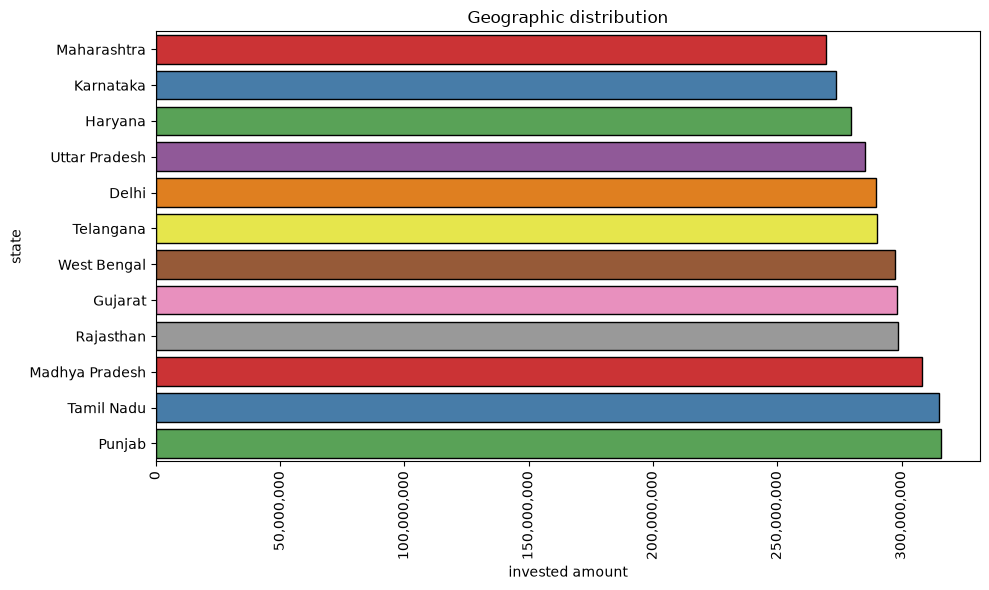

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
df=pd.read_csv("../data/processed/clean_investor_transactions.csv")

state_sip=(
    df.groupby('state')['amount_inr'].sum().sort_values().reset_index()
)
plt.figure(figsize=(10,6))
print(state_sip)

ax=sns.barplot(
    state_sip,
    x="amount_inr",
    y='state',
    hue='state',
    palette='Set1',
    edgecolor='black',
    linewidth=1
)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


plt.title('Geographic distribution')
plt.xlabel('invested amount')
plt.ylabel('state')

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()



city_tier
B30    1202325640
T30    2319254790
Name: amount_inr, dtype: int64


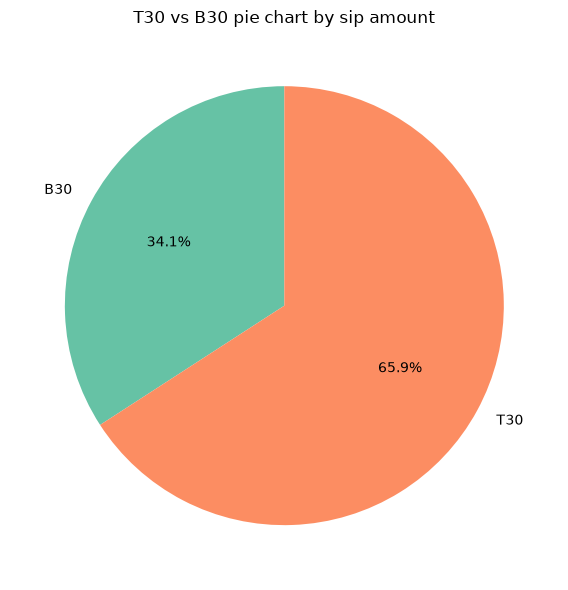

In [21]:
# t30 vs b30 piechart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("../data/processed/clean_investor_transactions.csv")
df['city_tier'].value_counts()

tier_data=(
    df.groupby("city_tier")['amount_inr'].sum())

print(tier_data)

plt.figure(figsize=(6,6))

plt.pie(
    tier_data.values,
    labels=['B30','T30'],
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set2.colors,
    explode=(0,0)
)
plt.title('T30 vs B30 pie chart by sip amount')
plt.tight_layout()
plt.show()


C:\Users\TULASI V\AppData\Local\Temp\ipykernel_13864\1755776982.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


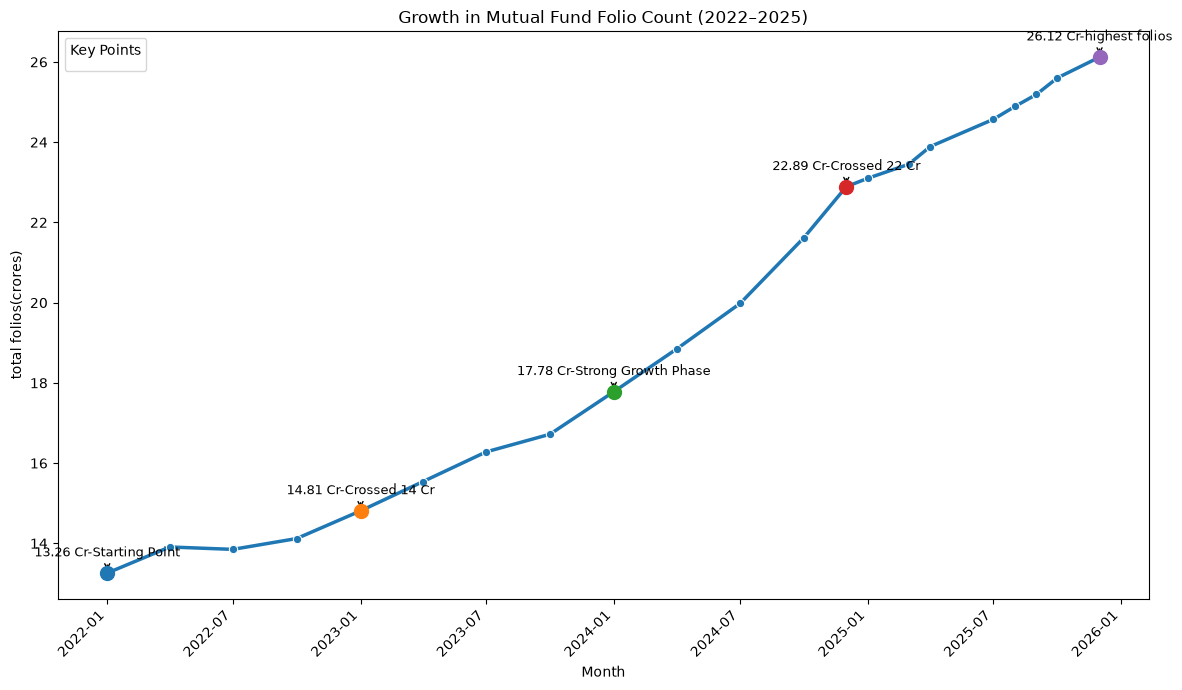

In [ ]:
# Folio Count Growth — Line Chart Template (Jan 2022 → Dec 2025)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('../data/raw/06_industry_folio_count.csv')

df['month']=pd.to_datetime(df['month'])

df=df.sort_values('month').reset_index(drop=True)

plt.figure(
    figsize=(12,7)
)
type(df)
sns.lineplot(
    data=df,
    x='month',
    y='total_folios_crore',
    marker='o',
    linewidth=2.5,
    linestyle='-'

)

milestones = {
    "2022-01": "13.26 Cr-Starting Point",
    "2023-01": "14.81 Cr-Crossed 14 Cr",
    "2024-01": "17.78 Cr-Strong Growth Phase",
    "2024-12": "22.89 Cr-Crossed 22 Cr",
    "2025-12": "26.12 Cr-highest folios"
}


for date, label in milestones.items():

    row = df.loc[df["month"] == date]
    

    if not row.empty:

        x = row["month"].values[0]
        y = row["total_folios_crore"].values[0]

        plt.scatter(
            x,
            y,
            s=100,
            zorder=6
        )

        plt.annotate(
            label,
            xy=(x, y),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            arrowprops=dict(
                arrowstyle="->",
                lw=1
            )
        )

plt.title("Growth in Mutual Fund Folio Count (2022–2025)",)
plt.xlabel("Month&Year")
plt.ylabel("total folios(crores)")

plt.xticks(rotation=45,ha='right')

plt.yticks(fontsize=10)


plt.legend(
    loc="upper left",
    title="Key Points"
)

plt.tight_layout()
plt.show()


amfi_code      int64
date             str
nav          float64
dtype: object


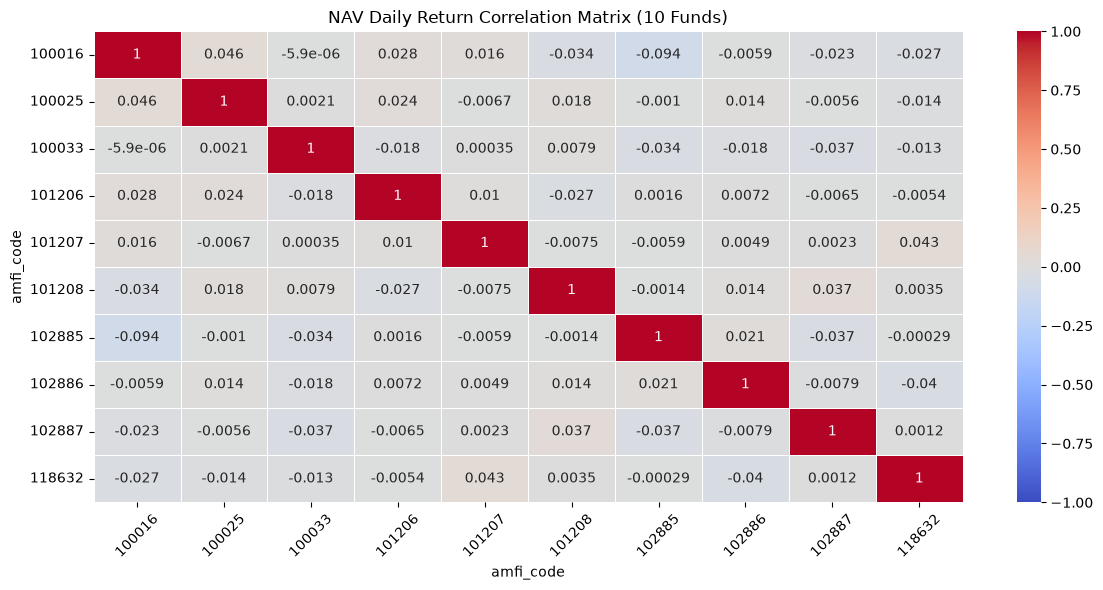

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# STEP 1: Load data
# ----------------------------
df = pd.read_csv("../data/processed/nav_history_clean.csv")
print(df.dtypes)
df['date'] = pd.to_datetime(df['date'])

# ----------------------------
# STEP 2: Convert long → wide format
# ----------------------------
nav_wide = df.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

# ----------------------------
# STEP 3: Sort dates
# ----------------------------
nav_wide = df.pivot(index='date', columns='amfi_code', values='nav')

# ----------------------------
# STEP 4: Compute daily returns
# ----------------------------
returns = nav_wide.pct_change().dropna()

# ----------------------------
# STEP 5: Select 10 funds (CORRECT)
# ----------------------------
selected_funds = [
    100016, 100025, 100033, 101206, 101207,
    101208, 102885, 102886, 102887, 118632
]

# IMPORTANT: select from returns, not list
returns_selected = returns[selected_funds]

# ----------------------------
# STEP 6: Correlation matrix (FIXED)
# ----------------------------
corr_matrix = returns_selected.corr()

# ----------------------------
# STEP 7: Heatmap
# ----------------------
plt.figure(figsize=(12,6))


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("NAV Daily Return Correlation Matrix (10 Funds)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

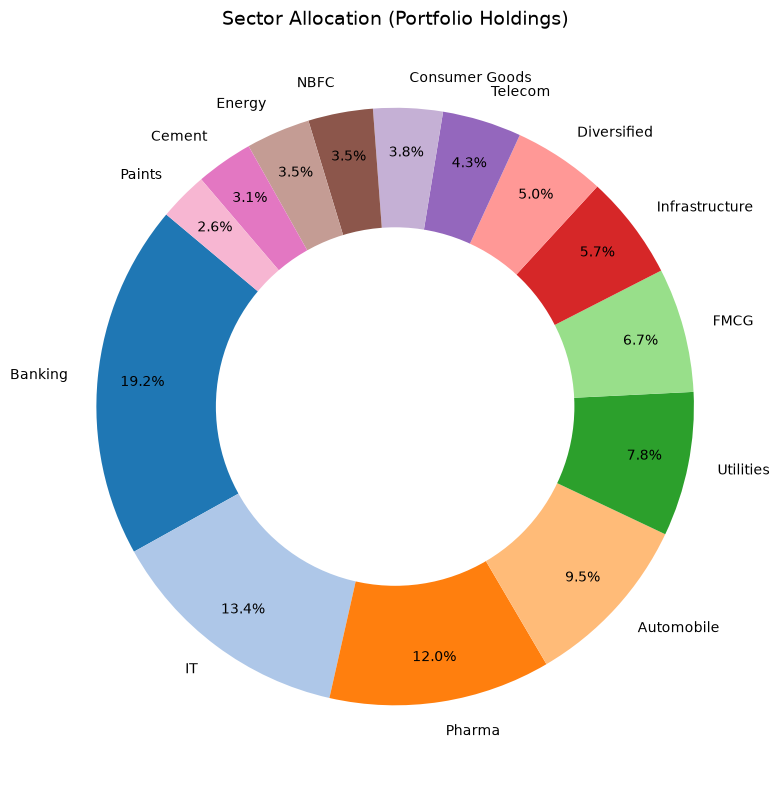

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# STEP 1: Load data
# ----------------------------
df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# ----------------------------
# STEP 2: Clean data
# ----------------------------
df = df.dropna(subset=["sector", "weight_pct"])

# ensure numeric
df["weight_pct"] = pd.to_numeric(df["weight_pct"], errors="coerce")
df = df.dropna(subset=["weight_pct"])

# ----------------------------
# STEP 3: Aggregate sector-wise allocation
# ----------------------------
sector_allocation = df.groupby("sector")["weight_pct"].sum()

# normalize to 100%
sector_allocation = sector_allocation / sector_allocation.sum() * 100

# sort for better visualization
sector_allocation = sector_allocation.sort_values(ascending=False)

# ----------------------------
# STEP 4: Plot Donut Chart
# ----------------------------
plt.figure(figsize=(10, 8))

colors = plt.cm.tab20.colors

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    pctdistance=0.85
)

# donut hole
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation (Portfolio Holdings)", fontsize=14)
plt.tight_layout()
plt.show()

        index_name   Highest    Lowest
0     BSE_SMALLCAP  79075.39  23592.64
1      CRISIL_GILT   2302.79   1444.13
2    CRISIL_LIQUID   3046.00   2281.51
3         NIFTY100  21088.58  14128.86
4          NIFTY50  27798.72  17492.79
5         NIFTY500  38418.87  14426.04
6  NIFTY_MIDCAP150  32990.66   8980.60


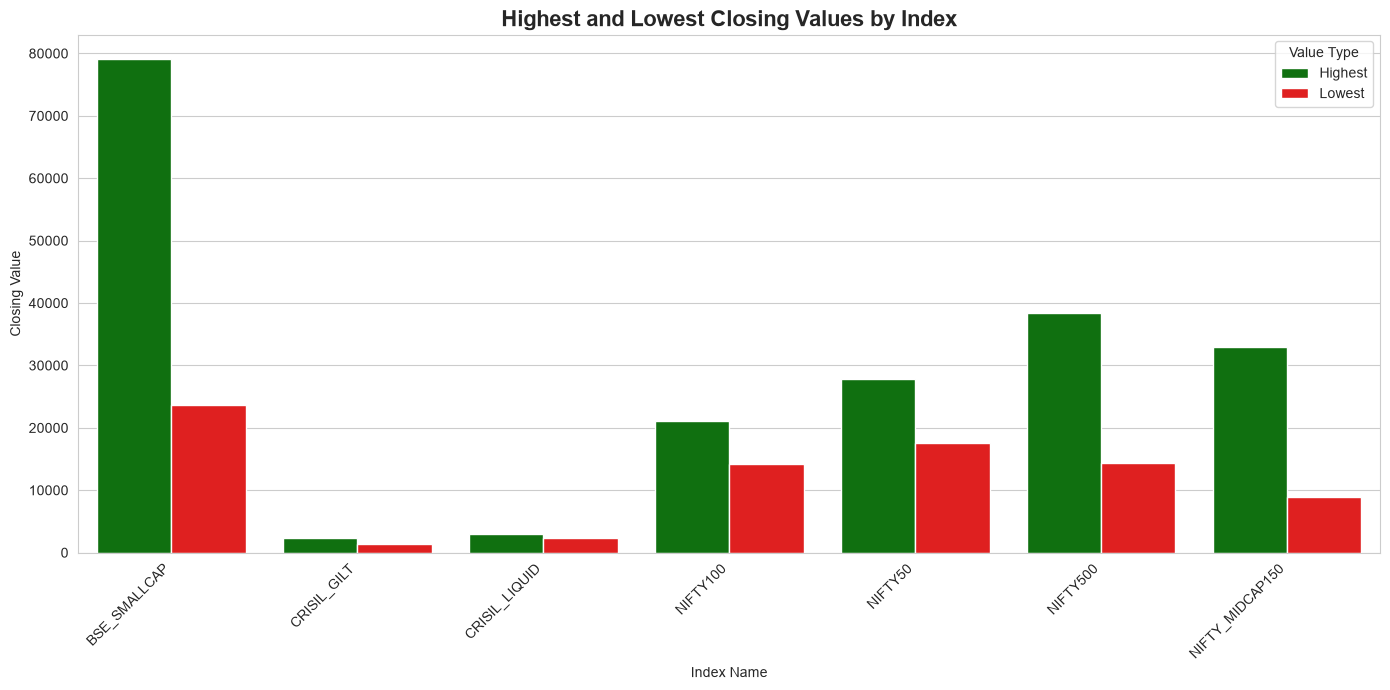

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/10_benchmark_indices.csv")
df["date"] = pd.to_datetime(df["date"])

summary = (
    df.groupby("index_name")["close_value"]
      .agg(Highest="max", Lowest="min")
      .reset_index()
)

print(summary)

# Convert to long format for Seaborn
plot_df = summary.melt(
    id_vars="index_name",
    value_vars=["Highest", "Lowest"],
    var_name="Type",
    value_name="Close_Value"
)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=plot_df,
    x="index_name",
    y="Close_Value",
    hue="Type",
    palette=["green", "red"]
)

plt.title("Highest and Lowest Closing Values by Index",
          fontsize=16, fontweight="bold")
plt.xlabel("Index Name")
plt.ylabel("Closing Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Value Type")

plt.tight_layout()
plt.show()

In [66]:
#below all charts are based on scheme performance.csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/raw/07_scheme_performance.csv")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

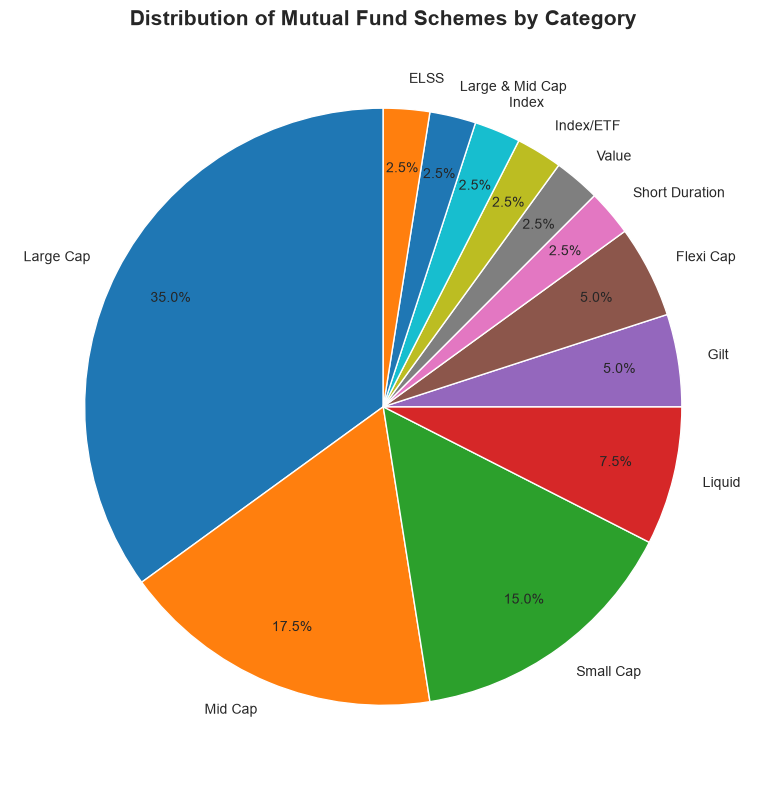

In [67]:
#Pie Chart – Scheme Distribution by Category
# Count number of schemes in each category
category_counts = df["category"].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

plt.title(
    "Distribution of Mutual Fund Schemes by Category",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

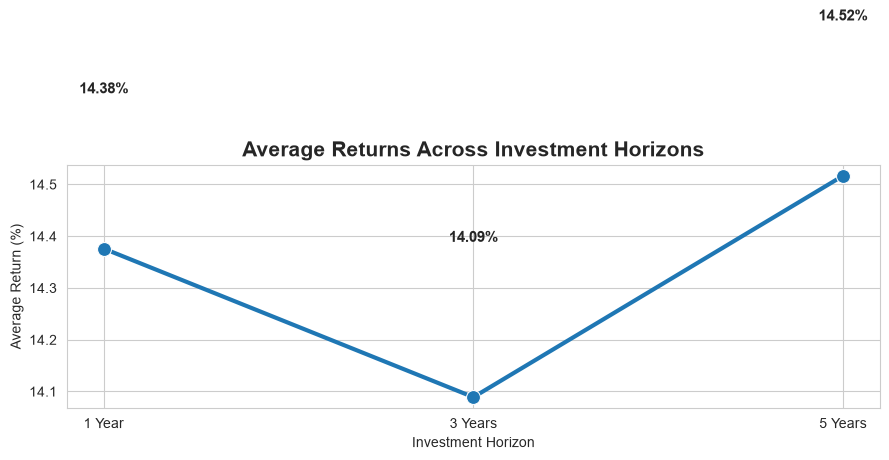

In [68]:
#Line Chart – Average Returns (1 Year, 3 Years, 5 Years)
# Calculate average returns
returns_df = pd.DataFrame({
    "Investment Horizon": [
        "1 Year",
        "3 Years",
        "5 Years"
    ],
    "Average Return (%)": [
        df["return_1yr_pct"].mean(),
        df["return_3yr_pct"].mean(),
        df["return_5yr_pct"].mean()
    ]
})

# Plot line chart
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=returns_df,
    x="Investment Horizon",
    y="Average Return (%)",
    marker="o",
    linewidth=3,
    markersize=10
)

# Add data labels
for i, value in enumerate(returns_df["Average Return (%)"]):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Returns Across Investment Horizons",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Investment Horizon")
plt.ylabel("Average Return (%)")

plt.tight_layout()
plt.show()

C:\Users\TULASI V\AppData\Local\Temp\ipykernel_13864\2635039050.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


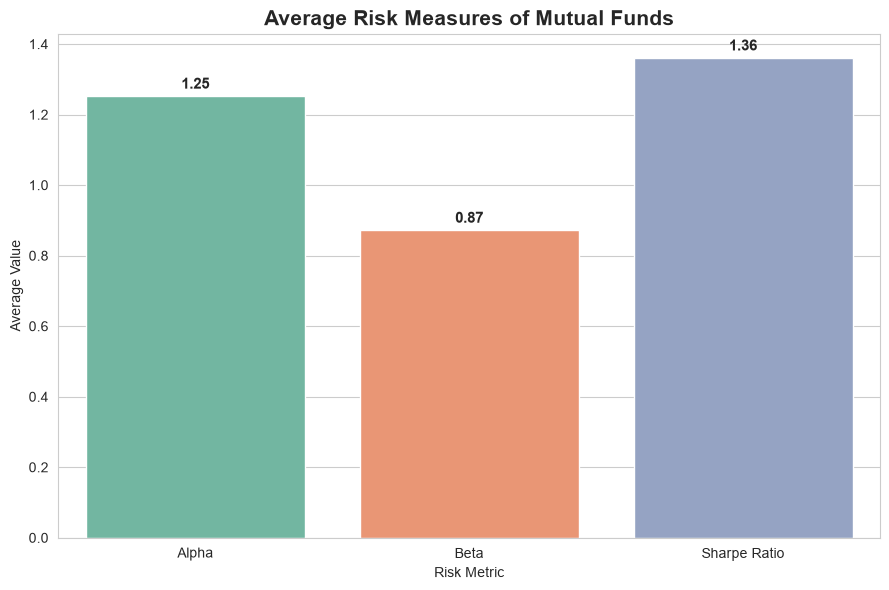

In [ ]:
#Bar Chart – Average Alpha, Beta and Sharpe Ratio irrespective of category,plan
# Calculate averages
risk_df = pd.DataFrame({
    "Metric": [
        "Alpha",
        "Beta",
        "Sharpe Ratio"
    ],
    "Average Value": [
        df["alpha"].mean(),
        df["beta"].mean(),
        df["sharpe_ratio"].mean()
    ]
})

# Plot bar chart
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=risk_df,
    x="Metric",
    y="Average Value",
    palette="Set2"
)

# Add value labels
for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Risk Measures of Mutual Funds",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Risk Metric")
plt.ylabel("Average Value")

plt.tight_layout()
plt.show()